In [3]:
%matplotlib notebook

In [4]:
import pandas as pd
import numpy as np
import re

#needed for text processing and analytics
import nltk
import nltk.stem

from nltk.tokenize import word_tokenize, sent_tokenize, PunktSentenceTokenizer
from nltk import pos_tag, sent_tokenize, word_tokenize, BigramAssocMeasures,\
    BigramCollocationFinder, TrigramAssocMeasures, TrigramCollocationFinder
from nltk.corpus import stopwords
from string import punctuation

#visualization
from plotly import tools
import plotly as py
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)
import plotly.graph_objs as go

import sys
import warnings

if not sys.warnoptions:
    warnings.simplefilter("ignore")


#to plot inside the document
%matplotlib inline
import matplotlib.pyplot as plt

# Any results you write to the current directory are saved as output.

In [5]:
#load the dataset
debates = pd.read_csv("/content/drive/MyDrive/SET A/un-general-debates.csv")

In [6]:
debates

,session,year,country,text
0,44,1989,MDV,﻿It is indeed a pleasure for me and the member...
1,44,1989,FIN,"﻿\nMay I begin by congratulating you. Sir, on ..."
2,44,1989,NER,"﻿\nMr. President, it is a particular pleasure ..."
3,44,1989,URY,﻿\nDuring the debate at the fortieth session o...
4,44,1989,ZWE,﻿I should like at the outset to express my del...
...,...,...,...,...
7502,56,2001,KAZ,﻿This session\nthat is taking place under extr...
7503,56,2001,LBR,﻿I am honoured to\nparticipate in this histori...
7504,56,2001,BDI,﻿It\nis for me a signal honour to take the flo...
7505,56,2001,HUN,"﻿First, may I congratulate Mr. Han Seung-soo o..."


In [7]:
debates.head()

,session,year,country,text
0,44,1989,MDV,﻿It is indeed a pleasure for me and the member...
1,44,1989,FIN,"﻿\nMay I begin by congratulating you. Sir, on ..."
2,44,1989,NER,"﻿\nMr. President, it is a particular pleasure ..."
3,44,1989,URY,﻿\nDuring the debate at the fortieth session o...
4,44,1989,ZWE,﻿I should like at the outset to express my del...


In [8]:
debates.tail()

,session,year,country,text
7502,56,2001,KAZ,﻿This session\nthat is taking place under extr...
7503,56,2001,LBR,﻿I am honoured to\nparticipate in this histori...
7504,56,2001,BDI,﻿It\nis for me a signal honour to take the flo...
7505,56,2001,HUN,"﻿First, may I congratulate Mr. Han Seung-soo o..."
7506,56,2001,KWT,"﻿On behalf of the State of Kuwait, it\ngives m..."


In [9]:
debates = debates.loc[debates['country'] == 'USA']

**Pre-Processing**

Text Processing will be done in two levels:-

*   Extracting meta text data and creating new features.
*   Process the text and create new features with tokens, cleaned text and stems.



In [10]:
# create features from meta text data
debates['char_count'] = debates['text'].str.len()
debates['words'] = debates['text'].str.split(' ')
debates['sentences'] = debates['text'].str.split('.')
debates['word_count'] = debates['words'].str.len()
debates['sentence_count'] = debates['sentences'].str.len()
debates['word_length'] = debates['char_count'] / debates['word_count']
debates['sentence_length'] = debates['word_count'] / debates['sentence_count']

<ipython-input-10-527070c13f55>:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-10-527070c13f55>:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-10-527070c13f55>:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-10-527070c






*   Tokenize - Tokenization is the task of chopping it up into pieces, called tokens , perhaps at the same time throwing away certain characters, such as punctuation.

*   Clean - Stop Word Removal is the process of removing the stop words. A stop word is a commonly used word (such as “the”, “a”, “an”, “in”) that a search engine has been programmed to ignore, both when indexing entries for searching and when retrieving them as the result of a search queries.

*   Stemmer - Stemming is the process of reducing inflected (or sometimes derived) words to their word stem, base or root form—generally a written word form.


*   Lemmatizer - Lemmatization usually refers to doing things properly with the use of a vocabulary and morphological analysis of words, normally aiming to remove inflectional endings only and to return the base or dictionary form of a word, which is known as the lemma .



In [11]:
import re
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from string import punctuation

# Sample data creation (assuming you have a DataFrame named 'debates')
# debates = pd.DataFrame({'text': ["Your sample text here"], 'year': [2023]})

# Ensure NLTK resources are downloaded
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Text processing
debates['text'] = debates['text'].str.lower().map(lambda x: re.sub('\W+', ' ', x))
debates['text'] = debates['text'].str.lower().map(lambda x: re.sub('united nations', 'united_nations', x))
debates['token'] = debates['text'].apply(word_tokenize)

# Stop words and additional tokens to remove
stop_words = set(stopwords.words('english'))
stop_words.update(["'s", "'", "-", "’"])

# Removing stop words and punctuation
debates['clean'] = debates['token'].apply(lambda x: [w for w in x if w not in stop_words and w not in punctuation])

# Function to get lemma of a word
from nltk.corpus import wordnet as wn

def get_lemma(word):
    lemma = wn.morphy(word)
    return word if lemma is None else lemma

# Stemming and lemmatizing
debates['stems'] = debates['clean'].apply(lambda x: [get_lemma(token) for token in x])

# Sorting the DataFrame by year
debates = debates.sort_values('year')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
<ipython-input-11-402a65c9cf71>:17: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-11-402a65c9cf71>:18: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-11-402a65c9cf71>:19: SettingWithCopyWarning:


A value

This code generates violin plots for the distributions of four meta text features in the 'debates' dataset: word count, average word length,sentence count, and average sentence length per speech. The plots display the spread and density of these features, along with the means, to visualize their variability across speeches.







<Figure size 1600x800 with 0 Axes>

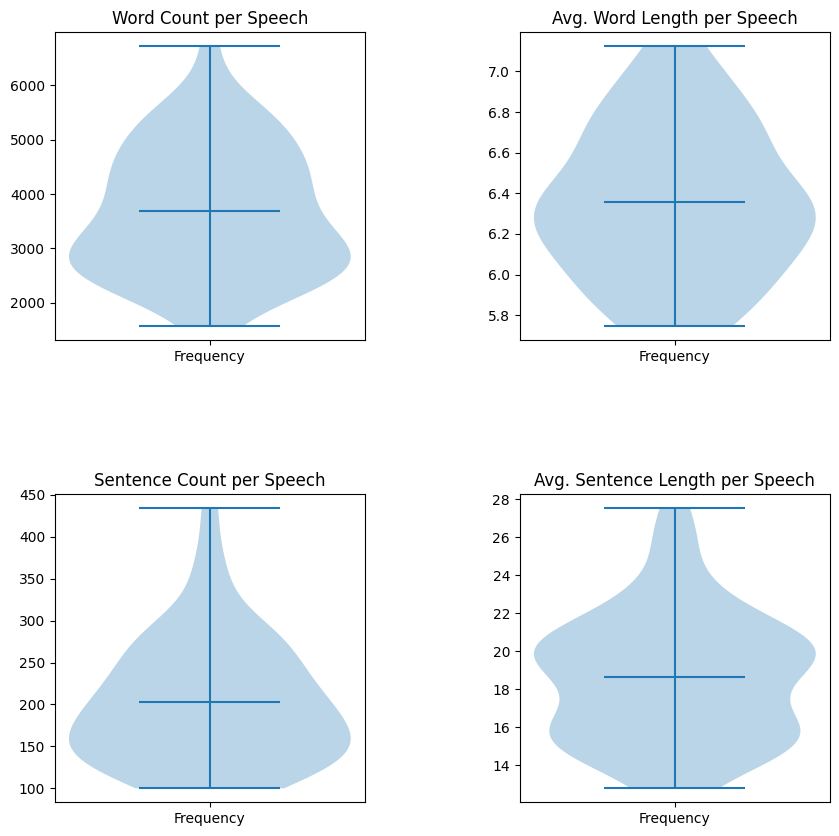

In [12]:
# Look at the meta text features' distributions
plt.figure(figsize=(16, 8))
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
all_data = [debates]

axes[0, 0].violinplot(debates['word_count'], showmeans=True, showmedians=False)
axes[0, 0].set_title('Word Count per Speech')

axes[0, 1].violinplot(debates['word_length'], showmeans=True, showmedians=False)
axes[0, 1].set_title('Avg. Word Length per Speech')

axes[1, 0].violinplot(debates['sentence_count'], showmeans=True, showmedians=False)
axes[1, 0].set_title('Sentence Count per Speech')

axes[1, 1].violinplot(debates['sentence_length'], showmeans=True, showmedians=False)
axes[1, 1].set_title('Avg. Sentence Length per Speech')

# add x-tick labels
plt.setp(axes, xticks=[y+1 for y in range(len(all_data))], xticklabels=['Frequency'])
fig.subplots_adjust(wspace=.5, hspace=.5)
plt.show()


This code creates and displays a Plotly interactive line chart that visualizes the trends of character count, word count, and sentence count over the years in the 'debates' dataset. Each line is filled to the next line to emphasize the area under the curves, providing a clear visual comparison of these text features across different years.

In [13]:
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode, iplot
import pandas as pd

# Assuming 'debates' is a pandas DataFrame with columns 'year', 'char_count', 'word_count', 'sentence_count'

trace1 = go.Scatter(
    x=debates['year'],
    y=debates['char_count'],
    fill='tonexty',
    name='Character Count'
)
trace2 = go.Scatter(
    x=debates['year'],
    y=debates['word_count'],
    fill='tonexty',
    name='Word Count'
)
trace3 = go.Scatter(
    x=debates['year'],
    y=debates['sentence_count'],
    fill='tonexty',
    name='Sentence Count'
)

data = [trace1, trace2, trace3]

# Initialize the notebook mode
init_notebook_mode(connected=True)

# Create the figure and display the plot
fig = go.Figure(data=data)
fig.show(renderer="colab")

This code groups the 'debates' dataset by 'session' and calculates the mean 'year' and the sum of 'clean' (possibly representing cleaned text or word count) for each session. The result is a DataFrame where each row corresponds to a session, showing the average year and the total cleaned text for that session.

In [14]:
all_per_year = debates.groupby('session').agg({'year': 'mean', 'clean': 'sum'})

This code generates a word cloud of the most frequently used words in the 'clean' text data from the 'all_per_year' DataFrame, excluding common English stopwords. The word cloud visually represents the frequency of words used in the US UN Debate sessions, with more frequently used words appearing larger.

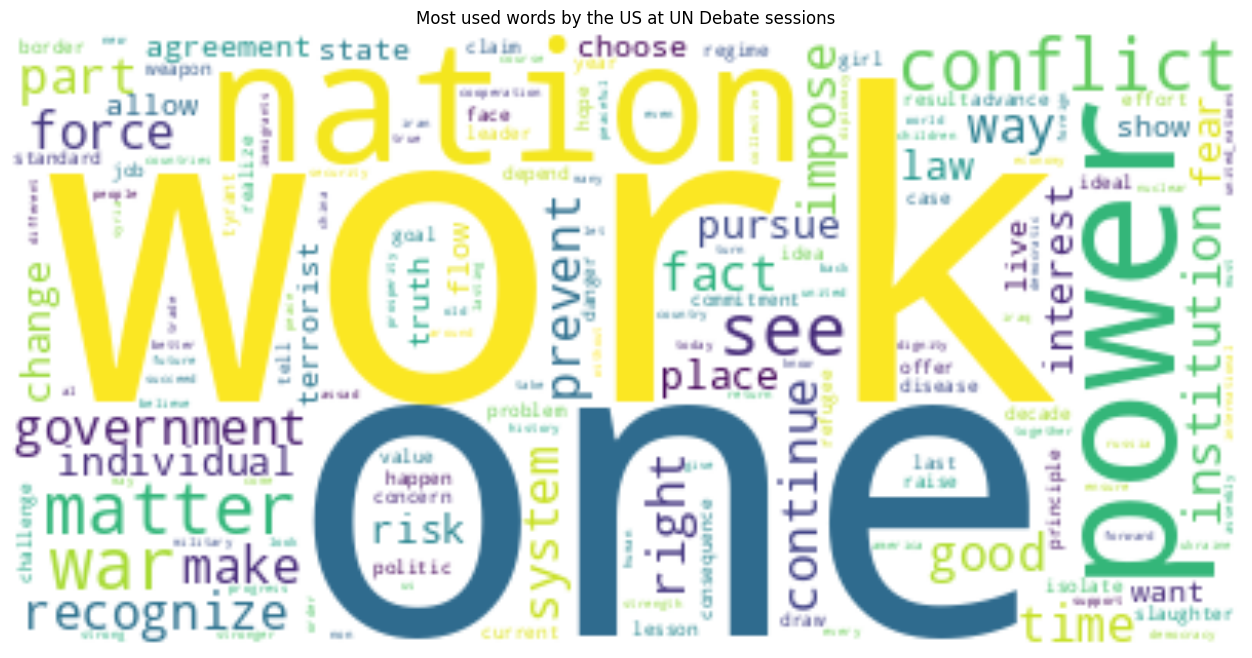

In [15]:
import nltk
from wordcloud import WordCloud, STOPWORDS

words = []
for i, row in all_per_year.iterrows():
    words = nltk.FreqDist(row['clean'])

words = nltk.FreqDist(words)
stopwords = nltk.corpus.stopwords.words('english')
words_except_stop_dist = nltk.FreqDist(w for w in words if w not in stopwords)
wordcloud = WordCloud(stopwords=STOPWORDS,background_color='white').generate(" ".join(words_except_stop_dist))
plt.imshow(wordcloud,interpolation='bilinear')
fig=plt.gcf()
fig.set_size_inches(16,8)
plt.title("Most used words by the US at UN Debate sessions")
plt.axis('off')
plt.show()

This code defines functions to generate and replace bigrams and trigrams in a text, enhancing word cloud visualizations by combining common word pairs and triplets. It also includes functions to process text by tokenizing, lemmatizing, and removing stopwords before applying bigram and trigram transformations.

In [16]:
#from https://www.kaggle.com/peterwittek/wordclouds-of-titles-and-abstracts-with-n-grams
#definations for Bi-Trigrams for Wordcloud viz
def get_bitrigrams(full_text, threshold=30):
    if isinstance(full_text, str):
        text = full_text
    else:
        text = " ".join(full_text)
    bigram_measures = BigramAssocMeasures()
    trigram_measures = TrigramAssocMeasures()
    finder = BigramCollocationFinder.from_words(text.split())
    finder.apply_freq_filter(3)
    bigrams = {" ".join(words): "_".join(words)
               for words in finder.above_score(bigram_measures.likelihood_ratio, threshold)}
    finder = TrigramCollocationFinder.from_words(text.split())
    finder.apply_freq_filter(3)
    trigrams = {" ".join(words): "_".join(words)
                for words in finder.above_score(trigram_measures.likelihood_ratio, threshold)}
    return bigrams, trigrams


def replace_bitrigrams(text, bigrams, trigrams):
    if isinstance(text, str):
        texts = [text]
    else:
        texts = text
    new_texts = []
    for t in texts:
        t_new = t
        for k, v in trigrams.items():
            t_new = t_new.replace(k, v)
        for k, v in bigrams.items():
            t_new = t_new.replace(" " + k + " ", " " + v + " ")
        new_texts.append(t_new)
    if len(new_texts) == 1:
        return new_texts[0]
    else:
        return new_texts

def process_text(text, lemmatizer, translate_table, stopwords):
    processed_text = ""
    for sentence in sent_tokenize(text):
        tagged_sentence = pos_tag(word_tokenize(sentence.translate(translate_table)))
        for word, tag in tagged_sentence:
            word = word.lower()
            if word not in stopwords:
                if tag[0] != 'V':
                    processed_text += lemmatizer.lemmatize(word) + " "
    return processed_text


def get_all_processed_texts(texts, lemmatizer, translate_table, stopwords):
    processed_texts = []
    for index, doc in enumerate(texts):
        processed_texts.append(process_text(doc, wordnet_lemmatizer, translate_table, stop))
    bigrams, trigrams = get_bitrigrams(processed_texts)
    very_processed_texts = replace_bitrigrams(processed_texts, bigrams, trigrams)
    return " ".join(very_processed_texts)

This code processes text data from US UN Debate sessions by tokenizing, lemmatizing, and removing stopwords, then generates and replaces bigrams to enhance the text. Finally, it creates and displays a word cloud highlighting the most frequently used bigrams in these debates.

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


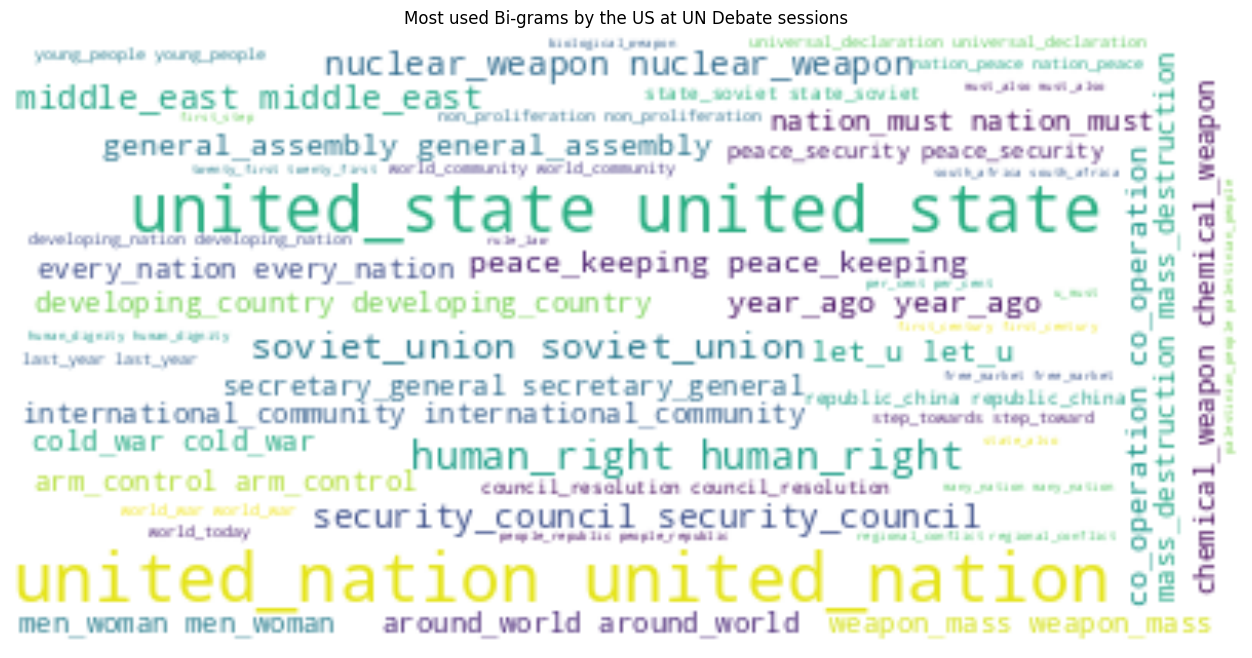

In [17]:
import nltk
from nltk.collocations import BigramCollocationFinder, BigramAssocMeasures
from nltk import WordNetLemmatizer
from wordcloud import WordCloud, STOPWORDS
from nltk.corpus import stopwords
import string
import matplotlib.pyplot as plt

# Download necessary NLTK resources
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')
nltk.download('wordnet')

wordnet_lemmatizer = WordNetLemmatizer()
stop = set(stopwords.words('english'))
translate_table = str.maketrans(string.punctuation, ' '*len(string.punctuation))

def process_text(doc, lemmatizer, translate_table, stopwords):
    tokens = doc.lower().translate(translate_table).split()
    return ' '.join([lemmatizer.lemmatize(word) for word in tokens if word not in stopwords])

def get_bitrigrams(processed_texts):
    bigram_measures = BigramAssocMeasures()
    finder = BigramCollocationFinder.from_documents([text.split() for text in processed_texts])
    finder.apply_freq_filter(3)  # Example filter, adjust as needed
    bigrams = {' '.join(bigram): '_'.join(bigram) for bigram, score in finder.score_ngrams(bigram_measures.pmi)}
    return bigrams, {}  # Empty trigram dict for simplicity

def use_ngrams_only(texts, lemmatizer, translate_table, stopwords):
    processed_texts = []
    for index, doc in enumerate(texts):
        processed_texts.append(process_text(doc, lemmatizer, translate_table, stopwords))
    bigrams, trigrams = get_bitrigrams(processed_texts)
    indexed_texts = []
    for doc in processed_texts:
        current_doc = []
        for k, v in trigrams.items():
            c = doc.count(k)
            if c > 0:
                current_doc += [v] * c
                doc = doc.replace(k, v)
        for k, v in bigrams.items():
            current_doc += [v] * doc.count(" " + k + " ")
        indexed_texts.append(" ".join(current_doc))
    return " ".join(indexed_texts)

wordcloud = WordCloud(stopwords=STOPWORDS, background_color="white").\
    generate(use_ngrams_only(debates['text'], wordnet_lemmatizer, translate_table, stop))
plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("Most used Bi-grams by the US at UN Debate sessions")
plt.axis("off")
plt.show()


**Finding Word Frequencies and Related Visualization**

In this section, first we find the frequency of different words used by the delegation in their speeches. Later, visualize them over to find particular patterns during the speeches over the years. Here, we take in consideration the stemmed words only because it makes more sense. For example, a stemmed word like terror make more sense than terrorist, terrorism, terrorising.

In [18]:
#creating frequency of words
freqs = {}
for i, speech in debates.iterrows():
    year = speech['year']
    for token in speech['stems']:
        if token not in freqs:
            freqs[token] = {"total_freq":1, year:1}
        else:
            freqs[token]["total_freq"] += 1
            if not freqs[token].get(year):
                freqs[token][year] = 1
            else:
                freqs[token][year] += 1

In [19]:
#create a dataframe to store the words and their frequencies
freqs_df = pd.DataFrame.from_dict(freqs, orient='index')
freqs_df['word'] = freqs_df.index
new_cols = ["total_freq", "word"] + sorted(freqs_df.columns.tolist()[1:-1])
freqs_df = freqs_df[new_cols]
freqs_df = freqs_df.sort_values('total_freq', ascending=False)
freqs_df = freqs_df.fillna(0)
freqs_df.head()

,total_freq,word,1970,1971,1972,1973,1974,1975,1976,1977,...,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
world,1065,world,21.0,25.0,16.0,25.0,39.0,28.0,28.0,21.0,...,22.0,22.0,19.0,33.0,30.0,22.0,25.0,28.0,37.0,27.0
state,972,state,48.0,30.0,33.0,20.0,25.0,46.0,49.0,25.0,...,10.0,17.0,5.0,13.0,17.0,24.0,7.0,44.0,12.0,25.0
nation,884,nation,11.0,7.0,6.0,10.0,28.0,22.0,41.0,43.0,...,13.0,26.0,26.0,45.0,11.0,17.0,7.0,19.0,16.0,29.0
united_nations,786,united_nations,54.0,23.0,22.0,8.0,6.0,21.0,17.0,4.0,...,6.0,16.0,21.0,9.0,7.0,11.0,6.0,8.0,4.0,8.0
must,775,must,8.0,14.0,17.0,17.0,19.0,22.0,28.0,13.0,...,14.0,11.0,31.0,29.0,18.0,36.0,26.0,16.0,14.0,13.0


In [31]:
# Create a scatter plot to visualize the top 100 words over the years
trace = go.Scatter(
    x=freqs_df.iloc[0:100]['word'],  # x-axis: words
    y=freqs_df.iloc[0:100]['total_freq'],  # y-axis: total frequency of words
    mode='lines+markers',
    name='Word Frequency'
)

# Define the layout for the plot
layout = dict(
    title='Frequency of Words Used Over Years',
    xaxis=dict(title='Word'),
    yaxis=dict(title='Count')
)

# Create the figure and display the plot
fig = go.Figure(data=[trace], layout=layout)
fig.show(renderer="colab", filename='basic-line')

Here we try to visualize the most frequent words ( top five ) every year from 1971 to 2016.

In [38]:
import plotly.graph_objects as go

# Define the range of years
RANGE = (1971, 2016)

# Create a scatter plot to visualize the top words over the years
fig = go.Figure()

for year in range(*RANGE):
    top5 = freqs_df.nlargest(5, columns=(year))  # Ensure the year is a string

    fig.add_trace(go.Scatter(
        x=[year]*len(top5),
        y=top5[(year)],
        mode='markers+text',
        text=top5['word'],
        textposition='top center',
        marker=dict(size=10),
        name=str(year)
    ))

# Update layout to make it visually appealing
fig.update_layout(
    title='Top 5 Words Used Over the Years',
    xaxis=dict(title='Year', tickmode='linear', tick0=RANGE[0], dtick=1, range=RANGE),
    yaxis=dict(title='Frequency'),
    showlegend=False,
    hovermode='closest',
    width=1200,
    height=600
)

# Display the plot
fig.show(renderer="colab")


The above plot is a scatter plots.

**Topic Extraction using Gensim**

Gensim is a robust open-source vector space modeling and topic modeling toolkit implemented in Python. It uses NumPy, SciPy and optionally Cython for performance. Here, we use Gensim to get the topics in the text.

In [39]:
text_data = list(debates['clean'])

In [41]:
from gensim import corpora
dictionary = corpora.Dictionary(text_data)
corpus = [dictionary.doc2bow(text) for text in text_data]
#import pickle
#pickle.dump(corpus, open('corpus.pkl', 'wb'))
#dictionary.save('dictionary.gensim')

In [42]:
import gensim
ldamodel = gensim.models.ldamodel.LdaModel(corpus, num_topics = 10, id2word=dictionary, passes=15)
ldamodel.save('model10.gensim')
topics = ldamodel.print_topics(num_words=10)
for topic in topics:
    print(topic)

(0, '0.009*"peace" + 0.008*"soviet" + 0.008*"world" + 0.008*"united" + 0.008*"states" + 0.007*"human" + 0.007*"rights" + 0.006*"united_nations" + 0.006*"war" + 0.006*"people"')
(1, '0.012*"states" + 0.010*"united" + 0.009*"world" + 0.008*"peace" + 0.007*"united_nations" + 0.007*"international" + 0.006*"must" + 0.006*"nations" + 0.004*"would" + 0.004*"new"')
(2, '0.000*"world" + 0.000*"states" + 0.000*"peace" + 0.000*"people" + 0.000*"nations" + 0.000*"united" + 0.000*"united_nations" + 0.000*"must" + 0.000*"international" + 0.000*"new"')
(3, '0.000*"must" + 0.000*"world" + 0.000*"people" + 0.000*"states" + 0.000*"peace" + 0.000*"nations" + 0.000*"united" + 0.000*"us" + 0.000*"united_nations" + 0.000*"international"')
(4, '0.013*"world" + 0.011*"people" + 0.010*"united_nations" + 0.010*"must" + 0.008*"nations" + 0.007*"states" + 0.007*"peace" + 0.006*"us" + 0.006*"new" + 0.006*"united"')
(5, '0.007*"world" + 0.007*"us" + 0.006*"peace" + 0.005*"must" + 0.005*"people" + 0.005*"united" + 0

I have commented the code the under mentioned. pyLDAvis changes the HTML too much and results in a weird view of the Kernel. While running locally one can uncomment an d visualize the topics, its very interesting.

In [44]:
!pip install pyLDAvis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 22.9 MB/s eta 0:00:00


In [45]:
import pyLDAvis.gensim
lda10 = gensim.models.ldamodel.LdaModel.load('model10.gensim')
lda_display10 = pyLDAvis.gensim.prepare(lda10, corpus, dictionary, sort_topics=False)
pyLDAvis.display(lda_display10)

In [46]:
print(text_data)

[['1', 'privilege', 'extend', 'warm', 'congratulations', 'united', 'states', 'delegation', 'election', 'presidency', 'twenty', 'fifth', 'session', 'general', 'assembly', 'country', 'peers', 'contributions', 'made', 'work', 'organization', 'father', 'leader', 'league', 'nations', 'session', 'general', 'assembly', 'adding', 'new', 'chapter', 'family', 'tradition', 'united_nations', 'community', 'long', 'known', 'able', 'spokesman', 'country', 'participant', 'life', 'united_nations', 'beginning', 'authority', 'charter', 'leading', 'scholar', 'practitioner', 'international', 'law', 'one', 'whose', 'personal', 'outlook', 'strongly', 'humanitarian', 'imbued', 'hope', 'determination', 'better', 'future', 'indeed', 'fortunate', 'lead', 'us', 'session', 'devoted', 'strengthening', 'improvement', 'united_nations', '2', 'session', 'shall', 'commemorate', 'fitting', 'ceremony', 'one', 'creative', 'hopeful', 'events', 'century', 'founding', 'united_nations', 'twenty', 'five', 'years', 'ago', 'right

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [47]:
from gensim import corpora, models
dictionary = corpora.Dictionary(text_data)
corpus = [dictionary.doc2bow(text) for text in text_data]
ldamodel = models.ldamodel.LdaModel(corpus, id2word=dictionary,
                                    num_topics=10, passes=5, minimum_probability=0)

hm = np.array([[y for (x,y) in ldamodel[corpus[i]]] for i in range(len(corpus))], dtype=object)
print(hm)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



[[3.3173656e-05 3.3181048e-05 3.317377e-05 0.9997014 3.3174143e-05
  3.317869e-05 3.3180353e-05 3.3179695e-05 3.317354e-05 3.3174296e-05]
 [3.9121573e-05 3.9129893e-05 3.9121736e-05 3.9131246e-05 3.912219e-05
  3.912755e-05 3.912877e-05 0.99964786 3.9121438e-05 3.9122377e-05]
 [4.8395774e-05 4.8408896e-05 4.8395952e-05 0.99956435 4.8396498e-05
  4.8403377e-05 4.8405225e-05 4.8407575e-05 4.8395657e-05 4.839667e-05]
 [6.926867e-05 6.92853e-05 6.926891e-05 0.9993765 6.9269714e-05
  6.928043e-05 6.928315e-05 6.928083e-05 6.9268455e-05 6.926997e-05]
 [4.2515683e-05 0.8463812 4.2515916e-05 0.15327874 4.251626e-05
  4.252195e-05 4.2524425e-05 4.2523006e-05 4.2515556e-05 4.2516513e-05]
 [3.3640063e-05 3.3648477e-05 3.3640168e-05 0.9996972 3.3640517e-05
  3.36453e-05 3.3646535e-05 3.364572e-05 3.363996e-05 3.3640703e-05]
 [2.6414604e-05 0.15486866 2.641469e-05 0.84492 2.6414922e-05
  2.6418847e-05 2.6420345e-05 2.6418891e-05 2.64145e-05 2.6415031e-05]
 [5.5792218e-05 0.9975857 5.579242e-05 0.00

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



<Axes: title={'center': 'Most common words'}>

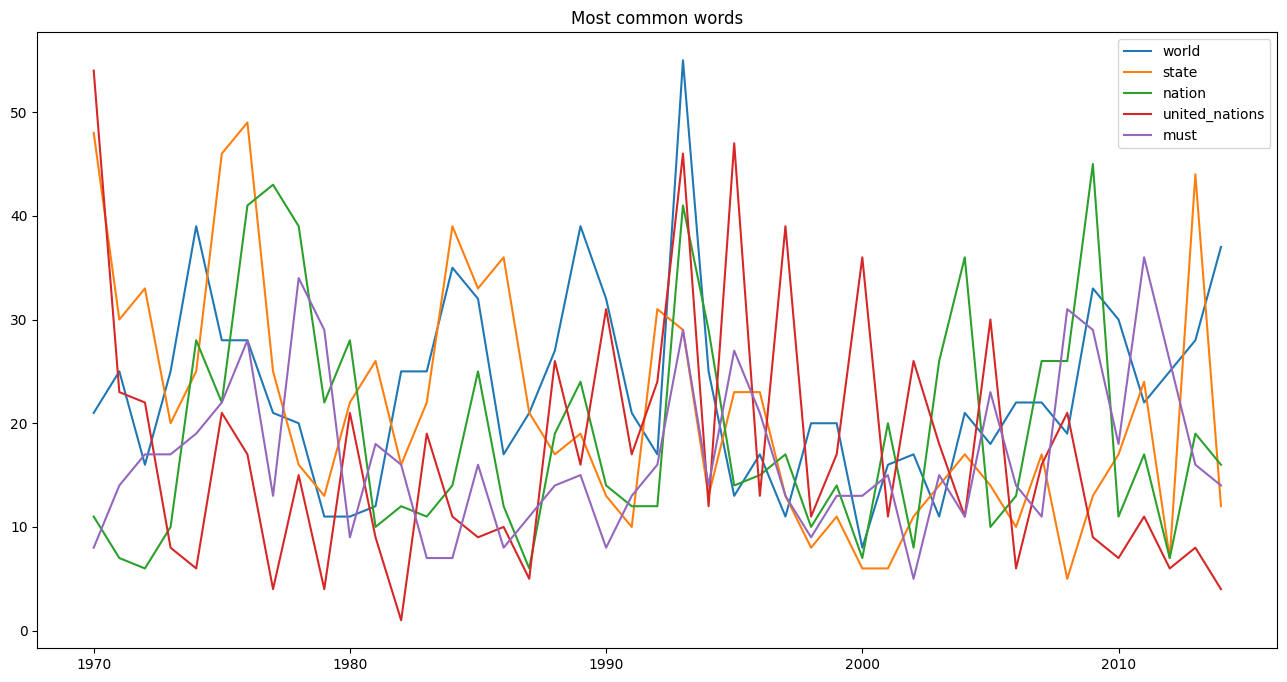

In [48]:
freqs_df.iloc[0:5, 1:47].transpose().iloc[1:].plot(title="Most common words",figsize=(16,8))

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



<Axes: title={'center': 'War and Peace'}>

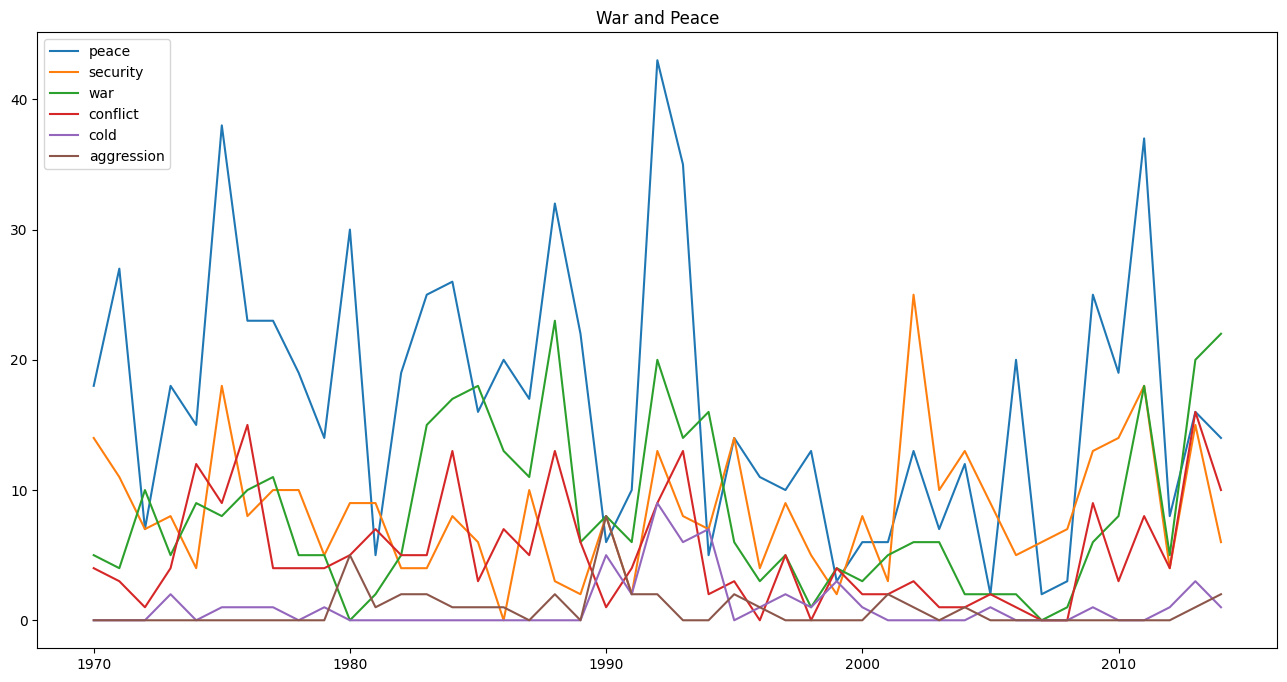

In [49]:
freqs_df[freqs_df['word'].isin(['peace', 'war', 'security', 'cold', 'conflict', 'aggression'])].iloc[:, 1:47].transpose().iloc[1:].plot(title = "War and Peace",figsize=(16,8))

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



<Axes: title={'center': 'Economy'}>

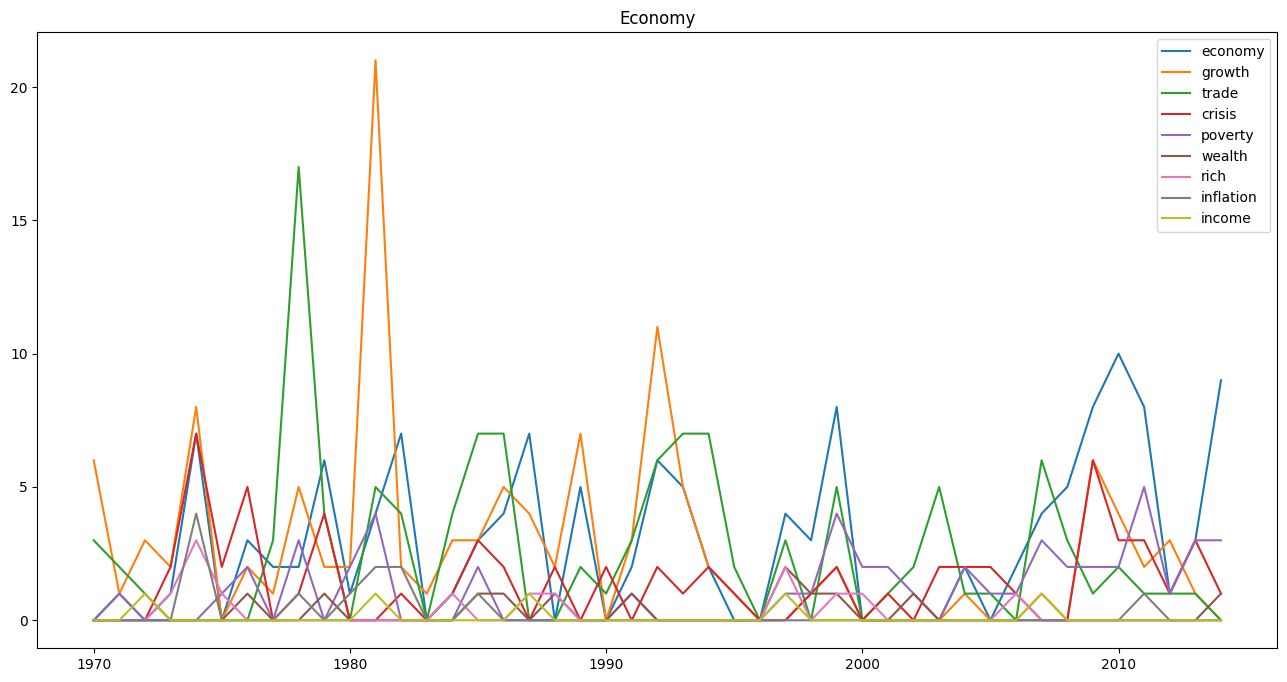

In [50]:
freqs_df[freqs_df['word'].isin(['economy', 'wealth', 'crisis', 'growth', 'inflation', 'trade', 'poverty', 'rich', 'income'])].iloc[:, 1:47].transpose().iloc[1:].plot(title="Economy",figsize=(16,8))

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



<Axes: title={'center': 'People'}>

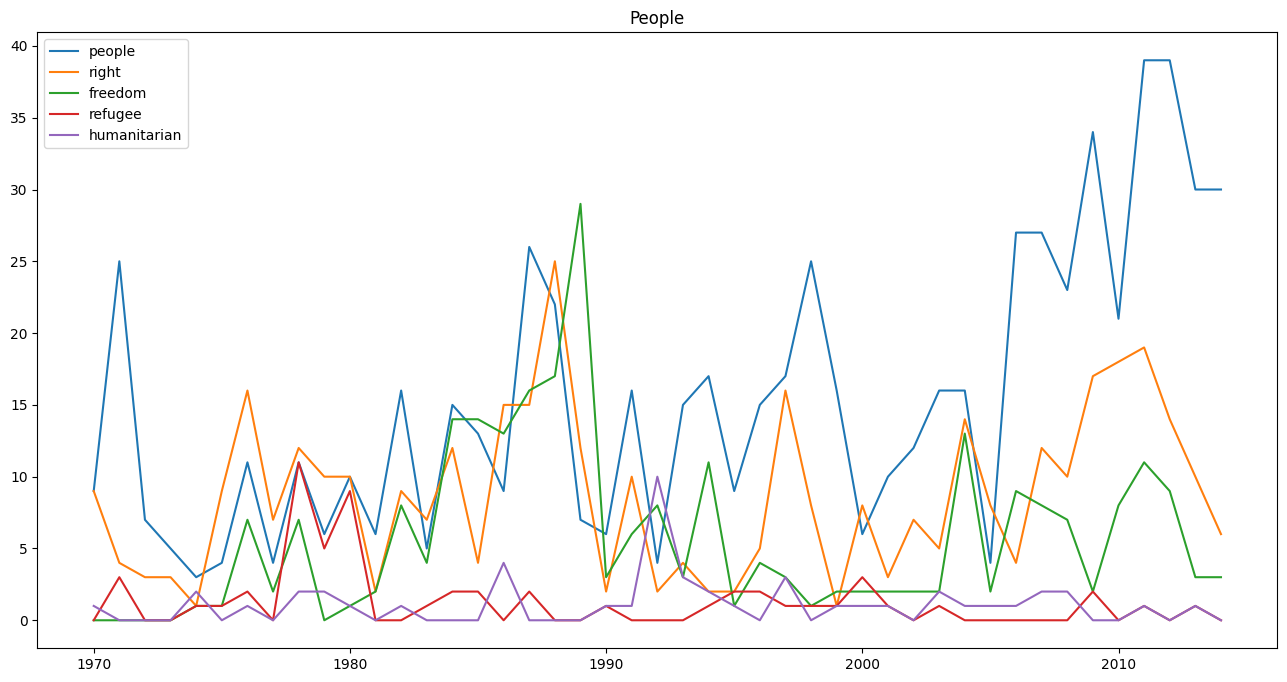

In [51]:
freqs_df[freqs_df['word'].isin(['people', 'refugee', 'humanitarian', 'freedom', 'right'])].iloc[:, 1:47].transpose().iloc[1:].plot(title="People",figsize=(16,8))

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



<Axes: title={'center': 'Politics'}>

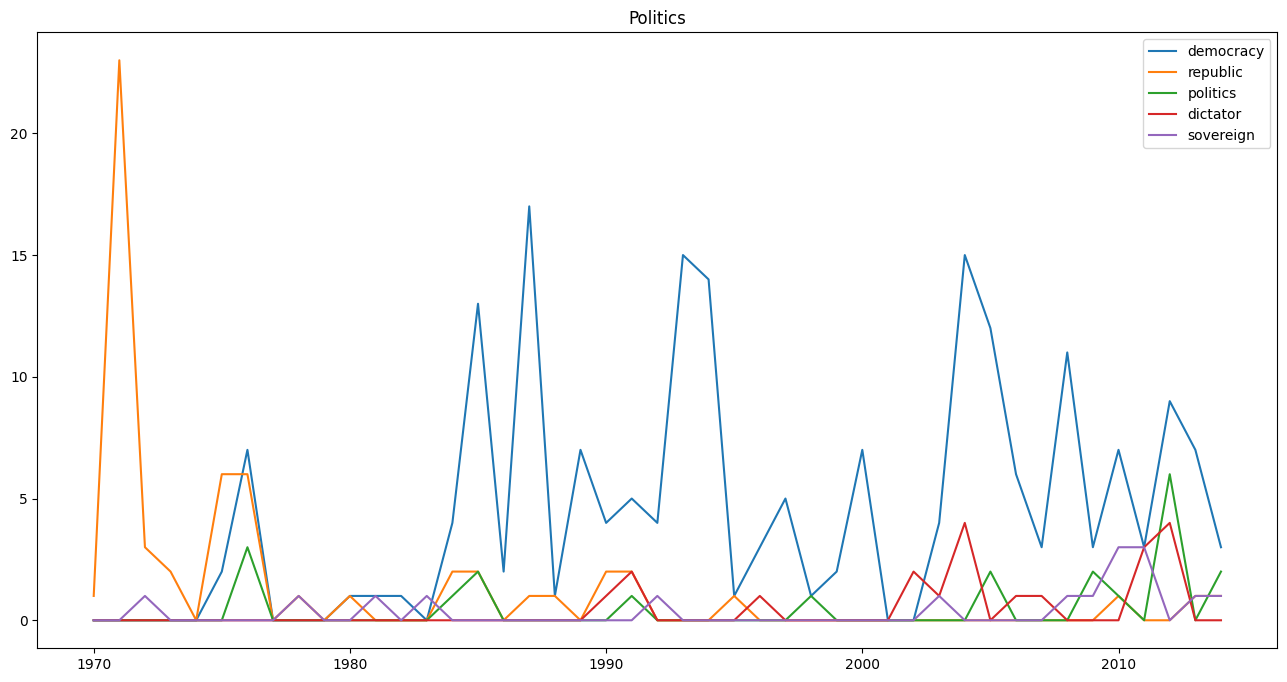

In [52]:
freqs_df[freqs_df['word'].isin(['democracy', 'republic', 'dictator', 'sovereign', 'politics'])].iloc[:, 1:47].transpose().iloc[1:].plot(title="Politics",figsize=(16,8))

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



<Axes: title={'center': 'Violence'}>

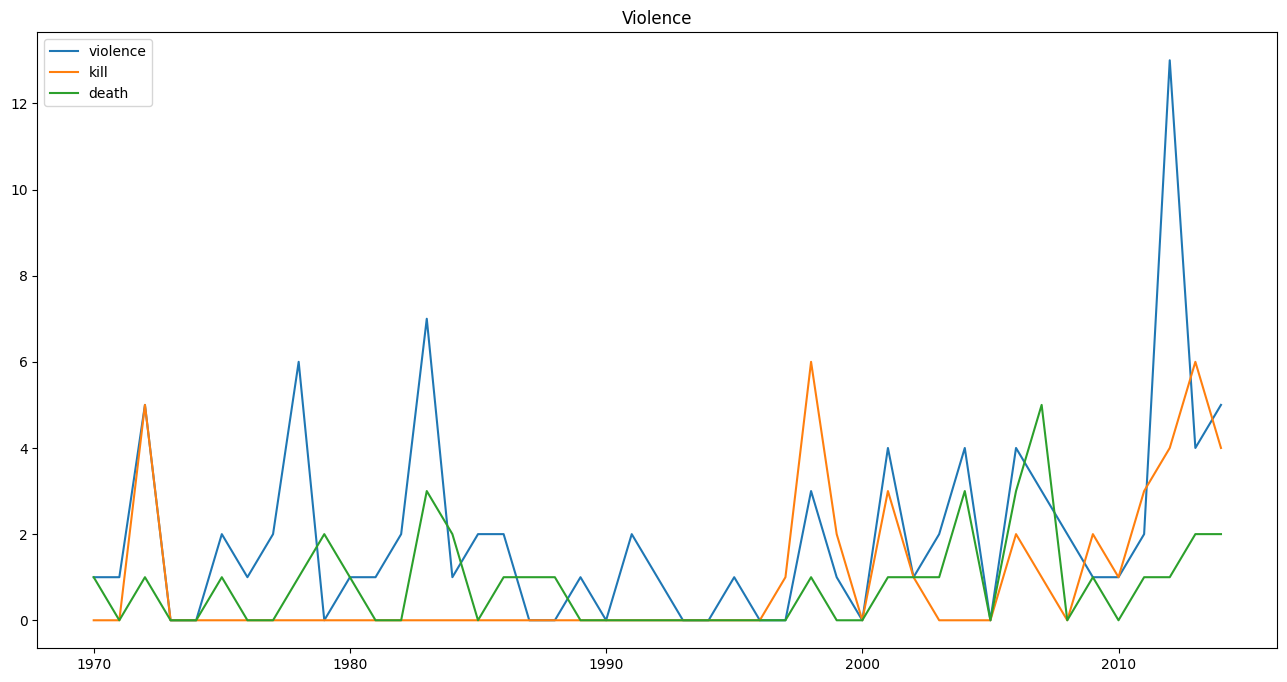

In [53]:
freqs_df[freqs_df['word'].isin(['violence', 'kill', 'death'])].iloc[:, 1:47].transpose().iloc[1:].plot(title="Violence",figsize=(16,8))

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



<Axes: title={'center': 'Environment'}>

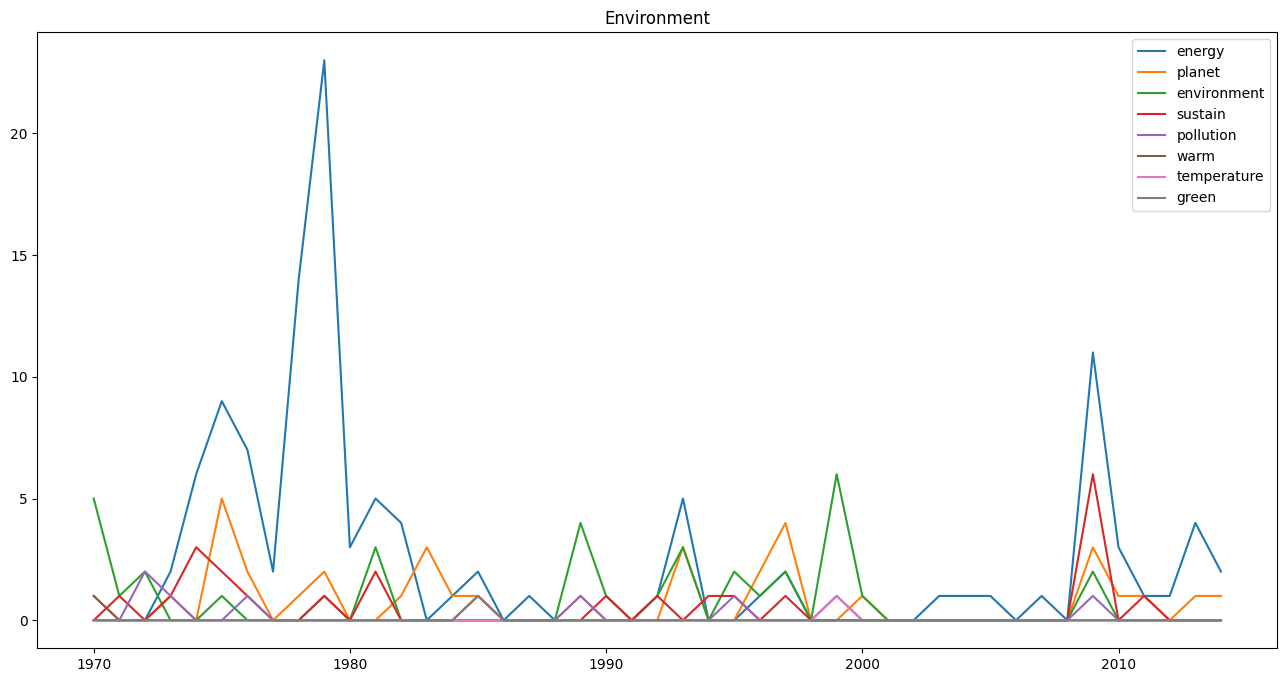

In [54]:
freqs_df[freqs_df['word'].isin(['environment', 'sustain', 'green', 'energy', 'ecology', 'warm', 'temperature', 'pollution', 'planet'])].iloc[:, 1:47].transpose().iloc[1:].plot(title="Environment",figsize=(16,8))

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



<Axes: title={'center': 'Terrorism'}>

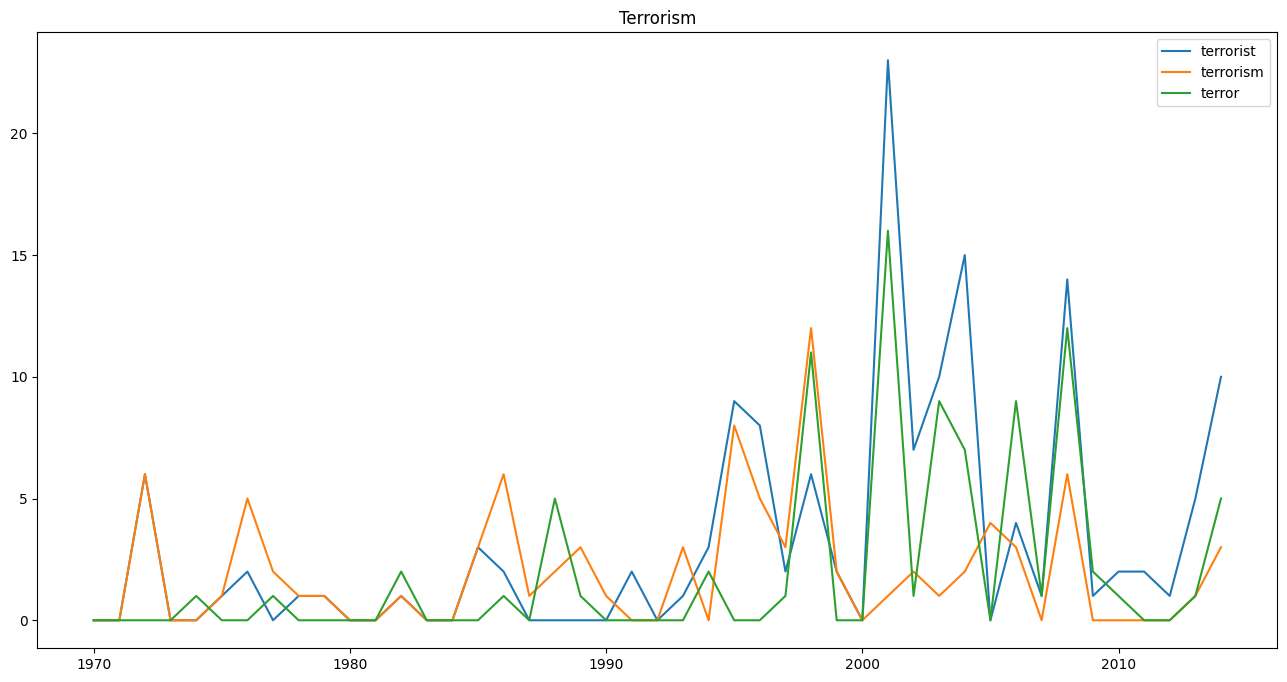

In [55]:
freqs_df[freqs_df['word'].isin(['terror','terrorism','terrorist'])].iloc[:, 1:47].transpose().iloc[1:].plot(title="Terrorism",figsize=(16,8))

**Countries mentioned by India and related Visualization**

In this section, we try to find the countries mentioned by India in the speeches over the years. First we obtain the list of countries from an external package and later we find the mention of the countries in the text. We create a new dataframe to store the frequencies of countries mentioned by India.

In [57]:
!pip install pycountry

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 19.9 MB/s eta 0:00:00


In [58]:
import pycountry
list_of_countries = []
for i in range(len(pycountry.countries)):
    x = list(pycountry.countries)[i]
    list_of_countries.append(x.name.lower())
print(list_of_countries)

['aruba', 'afghanistan', 'angola', 'anguilla', 'åland islands', 'albania', 'andorra', 'united arab emirates', 'argentina', 'armenia', 'american samoa', 'antarctica', 'french southern territories', 'antigua and barbuda', 'australia', 'austria', 'azerbaijan', 'burundi', 'belgium', 'benin', 'bonaire, sint eustatius and saba', 'burkina faso', 'bangladesh', 'bulgaria', 'bahrain', 'bahamas', 'bosnia and herzegovina', 'saint barthélemy', 'belarus', 'belize', 'bermuda', 'bolivia, plurinational state of', 'brazil', 'barbados', 'brunei darussalam', 'bhutan', 'bouvet island', 'botswana', 'central african republic', 'canada', 'cocos (keeling) islands', 'switzerland', 'chile', 'china', "côte d'ivoire", 'cameroon', 'congo, the democratic republic of the', 'congo', 'cook islands', 'colombia', 'comoros', 'cabo verde', 'costa rica', 'cuba', 'curaçao', 'christmas island', 'cayman islands', 'cyprus', 'czechia', 'germany', 'djibouti', 'dominica', 'denmark', 'dominican republic', 'algeria', 'ecuador', 'egy

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [60]:
debates['countries_mentioned'] = debates['token'].apply(lambda token: {x:token.count(x) for x in token if x in list_of_countries})

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [61]:
country_mentions = pd.concat([debates[["year"]],
                              debates['countries_mentioned'].apply(pd.Series)], axis=1).dropna(axis=1, how='all')
country_mentions = country_mentions.reset_index()
del country_mentions['index']
country_mentions.head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



,year,germany,china,congo,cyprus,mexico,honduras,bahrain,finland,brazil,...,liberia,morocco,spain,tunisia,malawi,senegal,ghana,mali,malaysia,singapore
0,1970,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1971,2.0,27.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1972,2.0,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1973,NaN,3.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1974,NaN,NaN,NaN,6.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [62]:
country_mentions = country_mentions.transpose()
country_mentions["total_mention"] = country_mentions.sum(axis=1)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [63]:
country_mentions = country_mentions.sort_values('total_mention', ascending=False)
country_mentions = country_mentions.transpose()
country_mentions = country_mentions.drop(country_mentions.index[len(country_mentions)-1])
country_mentions['year'] =country_mentions['year'].apply(np.int64)
country_mentions = country_mentions.sort_values('year')
country_mentions = country_mentions.fillna(0)
country_mentions.head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



,year,iraq,israel,afghanistan,china,lebanon,cyprus,namibia,ukraine,egypt,...,latvia,lithuania,armenia,jamaica,fiji,norway,eritrea,antarctica,serbia,singapore
0,1970,0.0,0.0,0.0,1.0,0.0,1.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1971,0.0,2.0,0.0,27.0,0.0,0.0,1.0,1.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1972,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1973,0.0,0.0,0.0,3.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1974,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



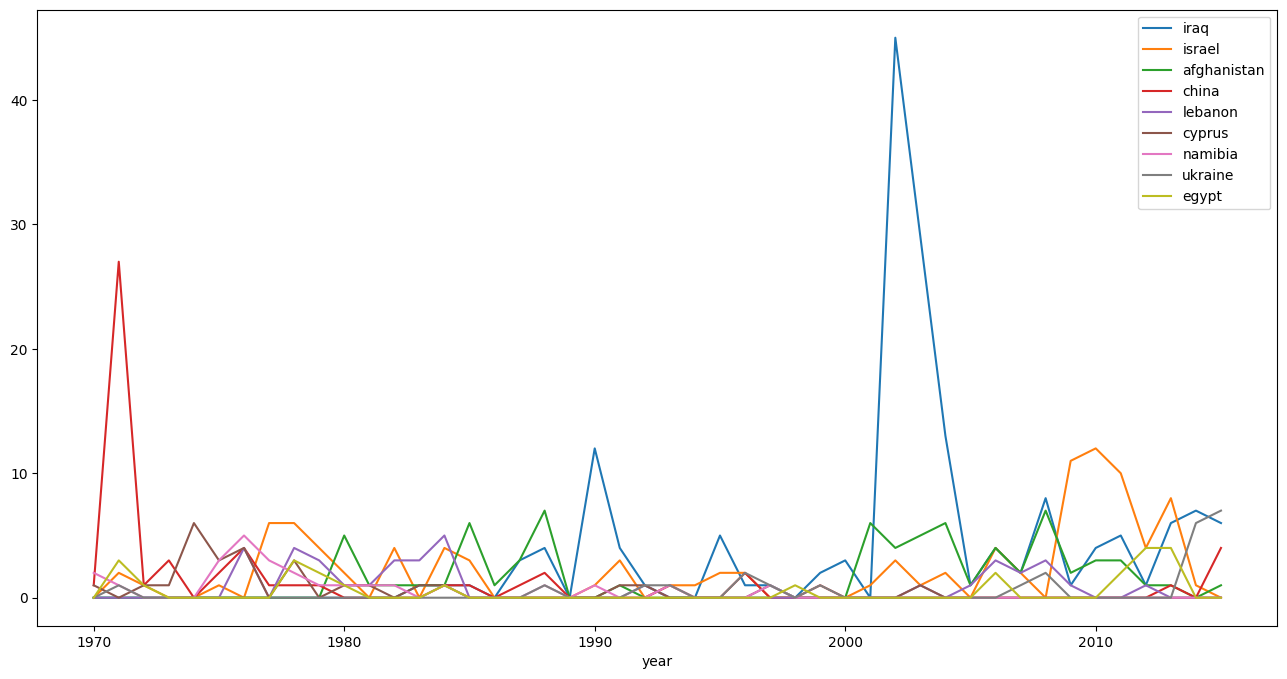

In [64]:
country_mentions.plot(x="year", y=["iraq","israel","afghanistan","china","lebanon","cyprus","namibia","ukraine","egypt"],figsize=(16,8))
plt.show()

In [65]:
country_mentions = country_mentions.rename_axis(None)
country_mentions = country_mentions.set_index('year').T
country_mentions['country'] = country_mentions.index

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [69]:
import plotly.express as px
import pandas as pd

# Assuming 'country_mentions' is your DataFrame with country mentions by year
# Replace this with the actual DataFrame creation/loading code if necessary

# Flatten the data for easier plotting with Plotly
data = []
for year in range(1971, 2016):
    top5 = country_mentions.nlargest(5, columns=year)
    for _, row in top5.iterrows():
        data.append({'Year': year, 'Country': row['country'], 'Mentions': row[year]})

# Convert to DataFrame
plot_df = pd.DataFrame(data)

# Create scatter plot with Plotly
fig = px.scatter(plot_df, x='Year', y='Mentions', color='Country',
                 hover_data={'Year': True, 'Country': True, 'Mentions': True},
                 title="Top 5 Country Mentions by Year")

# Show the plot
fig.show(renderer="colab")


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



Sentiment Analysis of Speech In this section we try analyze the sentiment of speeches given by Indian Delegation at the United Nations debates. We make use of a simple Sentiment Analyzer named Vader from NLTK.



In [70]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

def analize_sentiment(text):
    sid = SentimentIntensityAnalyzer()
    ss = sid.polarity_scores(text)
    if ss["compound"] == 0.0:
        sent = 0.0
    elif ss["compound"] > 0.0:
        sent = 1.0
    else:
        sent = -1.0
    return ss["compound"]

def analize_polarity(text):
    sid = SentimentIntensityAnalyzer()
    ss = sid.polarity_scores(text)
    if ss["compound"] == 0.0:
        sent = "Neutral"
    elif ss["compound"] > 0.0:
        sent = "Postive"
    else:
        sent = "Negative"
    return sent

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [72]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import numpy as np
import pandas as pd

# Download the VADER lexicon
nltk.download('vader_lexicon')

# Initialize the VADER sentiment analyzer
sid = SentimentIntensityAnalyzer()

# Define the sentiment analysis function
def analize_sentiment(text):
    return sid.polarity_scores(text)['compound']

# Define the polarity analysis function if different from sentiment
def analize_polarity(text):
    scores = sid.polarity_scores(text)
    return scores['pos'] - scores['neg']

# Assuming 'debates' is your DataFrame
debates['sentiment'] = np.array([analize_sentiment(text) for text in debates['text']])
debates['polarity'] = np.array([analize_polarity(text) for text in debates['text']])
debates.head()


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


,session,year,country,text,char_count,words,sentences,word_count,sentence_count,word_length,sentence_length,token,clean,stems,countries_mentioned,sentiment,polarity
161,25,1970,USA,1 it is my privilege to extend to you once aga...,34911,"[1.\t, It, is, my, privilege, to, extend, to, ...","[1, \t It is my privilege to extend to you onc...",5546,288,6.294807,19.256944,"[1, it, is, my, privilege, to, extend, to, you...","[1, privilege, extend, warm, congratulations, ...","[1, privilege, extend, warm, congratulations, ...","{'germany': 1, 'china': 1, 'congo': 1, 'cyprus...",1.0000,0.133
2967,26,1971,USA,mr president i should like first of all to as...,29393,"[, Mr., President,, I, should, like, first, of...","[ Mr, President, I should like first of all t...",4629,304,6.349752,15.226974,"[mr, president, i, should, like, first, of, al...","[mr, president, like, first, associate, previo...","[mr, president, like, first, associate, previo...","{'nigeria': 1, 'china': 27, 'japan': 1, 'germa...",1.0000,0.144
6864,27,1972,USA,during the past few years the world has made r...,23365,"[During, the, past, few, years, the, world, ha...",[During the past few years the world has made ...,3678,234,6.352637,15.717949,"[during, the, past, few, years, the, world, ha...","[past, years, world, made, remarkable, advance...","[past, years, world, make, remarkable, advance...","{'china': 1, 'france': 1, 'germany': 2, 'egypt...",0.9994,0.045
6578,28,1973,USA,35 i should like to add my congratulations to...,16222,"[﻿35.\tI, should, like, to, add, my, congratul...","[﻿35, \tI should like to add my congratulation...",2569,171,6.314519,15.023392,"[35, i, should, like, to, add, my, congratulat...","[35, like, add, congratulations, well, express...","[35, like, add, congratulations, well, express...","{'brazil': 1, 'ecuador': 1, 'china': 3, 'india...",0.9999,0.116
5262,29,1974,USA,last year at the previous session 2124th meeti...,26413,"[Last, year,, at, the, previous, session, [.21...","[Last year, at the previous session [, 2124th ...",4198,279,6.291806,15.046595,"[last, year, at, the, previous, session, 2124t...","[last, year, previous, session, 2124th, meetin...","[last, year, previous, session, 2124th, meetin...",{'cyprus': 6},0.9999,0.071


In [77]:
import plotly.graph_objects as go
from plotly.offline import iplot

data = [go.Bar(
           x=debates['year'],
           y=debates['sentiment']
    )]

fig = go.Figure(data=data)
fig.update_layout(title='Sentiment Analysis Over Years',
                  xaxis_title='Year',
                  yaxis_title='Sentiment Score')

fig.show(renderer="colab")

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [78]:
deb_values = debates.groupby(['polarity'],axis=0).count()
deb_values.head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



,session,year,country,text,char_count,words,sentences,word_count,sentence_count,word_length,sentence_length,token,clean,stems,countries_mentioned,sentiment
polarity,,,,,,,,,,,,,,,,
-0.078,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
-0.043,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
-0.028,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
-0.013,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
-0.010,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [85]:
label = ['Negative','Postive']
values = deb_values['text']
fig = go.Figure(data=[go.Pie(labels=label, values=values)])
fig.update_layout(title='Polarity of Speeches by USA')

fig.show(renderer="colab")

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



**Mention of US by Other countries**

In [97]:
data= pd.read_csv("/content/drive/MyDrive/SET A/un-general-debates.csv")
data.head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



,session,year,country,text
0,44,1989,MDV,﻿It is indeed a pleasure for me and the member...
1,44,1989,FIN,"﻿\nMay I begin by congratulating you. Sir, on ..."
2,44,1989,NER,"﻿\nMr. President, it is a particular pleasure ..."
3,44,1989,URY,﻿\nDuring the debate at the fortieth session o...
4,44,1989,ZWE,﻿I should like at the outset to express my del...


In [98]:
#create feature with text processing
data['text'] = data['text'].str.lower().map(lambda x: re.sub('\W+',' ', x))
data['token'] = data['text'].apply(word_tokenize)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.

<>:2: DeprecationWarning:

invalid escape sequence '\W'

<>:2: DeprecationWarning:

invalid escape sequence '\W'

<ipython-input-98-a1a97f830062>:2: DeprecationWarning:

invalid escape sequence '\W'



In [99]:
data['usa_mentioned'] = data.text.str.count('united states')
data = data[data.country != 'USA']
data.head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



,session,year,country,text,token,usa_mentioned
0,44,1989,MDV,it is indeed a pleasure for me and the member...,"[it, is, indeed, a, pleasure, for, me, and, th...",0
1,44,1989,FIN,may i begin by congratulating you sir on your...,"[may, i, begin, by, congratulating, you, sir, ...",1
2,44,1989,NER,mr president it is a particular pleasure for ...,"[mr, president, it, is, a, particular, pleasur...",3
3,44,1989,URY,during the debate at the fortieth session of ...,"[during, the, debate, at, the, fortieth, sessi...",0
4,44,1989,ZWE,i should like at the outset to express my del...,"[i, should, like, at, the, outset, to, express...",1


In [100]:
countries = dict((k, v.lower()) for k,v in {
    'AFG': 'Afghanistan',
    'ALA': 'Aland Islands',
    'ALB': 'Albania',
    'DZA': 'Algeria',
    'ASM': 'American Samoa',
    'AND': 'Andorra',
    'AGO': 'Angola',
    'AIA': 'Anguilla',
    'ATA': 'Antarctica',
    'ATG': 'Antigua and Barbuda',
    'ARG': 'Argentina',
    'ARM': 'Armenia',
    'ABW': 'Aruba',
    'AUS': 'Australia',
    'AUT': 'Austria',
    'AZE': 'Azerbaijan',
    'BHS': 'Bahamas',
    'BHR': 'Bahrain',
    'BGD': 'Bangladesh',
    'BRB': 'Barbados',
    'BLR': 'Belarus',
    'BEL': 'Belgium',
    'BLZ': 'Belize',
    'BEN': 'Benin',
    'BMU': 'Bermuda',
    'BTN': 'Bhutan',
    'BOL': 'Bolivia',
    'BIH': 'Bosnia and Herzegovina',
    'BWA': 'Botswana',
    'BVT': 'Bouvet Island',
    'BRA': 'Brazil',
    'VGB': 'Virgin Islands',
    'IOT': 'British Indian Ocean Territory',
    'BRN': 'Brunei',
    'BGR': 'Bulgaria',
    'BFA': 'Burkina Faso',
    'BDI': 'Burundi',
    'KHM': 'Cambodia',
    'CMR': 'Cameroon',
    'CAN': 'Canada',
    'CPV': 'Cape Verde',
    'CYM': 'Cayman Islands',
    'CAF': 'Central Africa',
    'TCD': 'Chad',
    'CHL': 'Chile',
    'CHN': 'China',
    'HKG': 'Hong Kong',
    'MAC': 'Macao',
    'CXR': 'Christmas Island',
    'CCK': 'Cocos Islands',
    'COL': 'Colombia',
    'COM': 'Comoros',
    'COG': 'Congo',
    'COD': 'Democratic Republic of Congo',
    'COK': 'Cook Islands',
    'CRI': 'Costa Rica',
    'CIV': "Cote d'Ivoire",
    'HRV': 'Croatia',
    'CUB': 'Cuba',
    'CYP': 'Cyprus',
    'CZE': 'Czech Republic',
    'DNK': 'Denmark',
    'DJI': 'Djibouti',
    'DMA': 'Dominica',
    'DOM': 'Dominican Republic',
    'ECU': 'Ecuador',
    'EGY': 'Egypt',
    'SLV': 'El Salvador',
    'GNQ': 'Equatorial Guinea',
    'ERI': 'Eritrea',
    'EST': 'Estonia',
    'ETH': 'Ethiopia',
    'FLK': 'Falkland',
    'FRO': 'Faroe',
    'FJI': 'Fiji',
    'FIN': 'Finland',
    'FRA': 'France',
    'GUF': 'French Guiana',
    'PYF': 'French Polynesia',
    'ATF': 'French Southern Territories',
    'GAB': 'Gabon',
    'GMB': 'Gambia',
    'GEO': 'Georgia',
    'DEU': 'Germany',
    'GHA': 'Ghana',
    'GIB': 'Gibraltar',
    'GRC': 'Greece',
    'GRL': 'Greenland',
    'GRD': 'Grenada',
    'GLP': 'Guadeloupe',
    'GUM': 'Guam',
    'GTM': 'Guatemala',
    'GGY': 'Guernsey',
    'GIN': 'Guinea',
    'GNB': 'Guinea-Bissau',
    'GUY': 'Guyana',
    'HTI': 'Haiti',
    'HMD': 'Heard and Mcdonald Islands',
    'VAT': 'Vatican',
    'HND': 'Honduras',
    'HUN': 'Hungary',
    'ISL': 'Iceland',
    'IND': 'India',
    'IDN': 'Indonesia',
    'IRN': 'Iran',
    'IRQ': 'Iraq',
    'IRL': 'Ireland',
    'IMN': 'Isle of Man',
    'ISR': 'Israel',
    'ITA': 'Italy',
    'JAM': 'Jamaica',
    'JPN': 'Japan',
    'JEY': 'Jersey',
    'JOR': 'Jordan',
    'KAZ': 'Kazakhstan',
    'KEN': 'Kenya',
    'KIR': 'Kiribati',
    'PRK': 'North Korea',
    'KOR': 'South Korea',
    'KWT': 'Kuwait',
    'KGZ': 'Kyrgyzstan',
    'LAO': 'Lao',
    'LVA': 'Latvia',
    'LBN': 'Lebanon',
    'LSO': 'Lesotho',
    'LBR': 'Liberia',
    'LBY': 'Libya',
    'LIE': 'Liechtenstein',
    'LTU': 'Lithuania',
    'LUX': 'Luxembourg',
    'MKD': 'Macedonia',
    'MDG': 'Madagascar',
    'MWI': 'Malawi',
    'MYS': 'Malaysia',
    'MDV': 'Maldives',
    'MLI': 'Mali',
    'MLT': 'Malta',
    'MHL': 'Marshall Islands',
    'MTQ': 'Martinique',
    'MRT': 'Mauritania',
    'MUS': 'Mauritius',
    'MYT': 'Mayotte',
    'MEX': 'Mexico',
    'FSM': 'Micronesia',
    'MDA': 'Moldova',
    'MCO': 'Monaco',
    'MNG': 'Mongolia',
    'MNE': 'Montenegro',
    'MSR': 'Montserrat',
    'MAR': 'Morocco',
    'MOZ': 'Mozambique',
    'MMR': 'Myanmar',
    'NAM': 'Namibia',
    'NRU': 'Nauru',
    'NPL': 'Nepal',
    'NLD': 'Netherlands',
    'ANT': 'Netherlands Antilles',
    'NCL': 'New Caledonia',
    'NZL': 'New Zealand',
    'NIC': 'Nicaragua',
    'NER': 'Niger',
    'NGA': 'Nigeria',
    'NIU': 'Niue',
    'NFK': 'Norfolk Island',
    'MNP': 'Northern Mariana Islands',
    'NOR': 'Norway',
    'OMN': 'Oman',
    'PAK': 'Pakistan',
    'PLW': 'Palau',
    'PSE': 'Palestine',
    'PAN': 'Panama',
    'PNG': 'Papua New Guinea',
    'PRY': 'Paraguay',
    'PER': 'Peru',
    'PHL': 'Philippines',
    'PCN': 'Pitcairn',
    'POL': 'Poland',
    'PRT': 'Portugal',
    'PRI': 'Puerto Rico',
    'QAT': 'Qatar',
    'REU': 'Reunion',
    'ROU': 'Romania',
    'RUS': 'Russia',
    'RWA': 'Rwanda',
    'BLM': 'Saint-Barthelemy',
    'SHN': 'Saint Helena',
    'KNA': 'Saint Kitts',
    'LCA': 'Saint Lucia',
    'MAF': 'Saint-Martin',
    'SPM': 'Saint Pierre and Miquelon',
    'VCT': 'Saint Vincent and Grenadines',
    'WSM': 'Samoa',
    'SMR': 'San Marino',
    'STP': 'Sao Tome and Principe',
    'SAU': 'Saudi Arabia',
    'SEN': 'Senegal',
    'SRB': 'Serbia',
    'SYC': 'Seychelles',
    'SLE': 'Sierra Leone',
    'SGP': 'Singapore',
    'SVK': 'Slovakia',
    'SVN': 'Slovenia',
    'SLB': 'Solomon Islands',
    'SOM': 'Somalia',
    'ZAF': 'South Africa',
    'SGS': 'South Georgia and the South Sandwich Islands',
    'SSD': 'South Sudan',
    'ESP': 'Spain',
    'LKA': 'Sri Lanka',
    'SDN': 'Sudan',
    'SUR': 'Suriname',
    'SJM': 'Svalbard',
    'SWZ': 'Swaziland',
    'SWE': 'Sweden',
    'CHE': 'Switzerland',
    'SYR': 'Syria',
    'TWN': 'Taiwan',
    'TJK': 'Tajikistan',
    'TZA': 'Tanzania',
    'THA': 'Thailand',
    'TLS': 'Timor',
    'TGO': 'Togo',
    'TKL': 'Tokelau',
    'TON': 'Tonga',
    'TTO': 'Trinidad',
    'TUN': 'Tunisia',
    'TUR': 'Turkey',
    'TKM': 'Turkmenistan',
    'TCA': 'Turks and Caicos Islands',
    'TUV': 'Tuvalu',
    'UGA': 'Uganda',
    'UKR': 'Ukraine',
    'ARE': 'United Arab Emirates',
    'GBR': 'United Kingdom',
    'USA': 'United States',
    'UMI': 'US Minor Outlying Islands',
    'URY': 'Uruguay',
    'UZB': 'Uzbekistan',
    'VUT': 'Vanuatu',
    'VEN': 'Venezuela',
    'VNM': 'Viet Nam',
    'VIR': 'Virgin Islands',
    'WLF': 'Wallis and Futuna',
    'ESH': 'Western Sahara',
    'YEM': 'Yemen',
    'ZMB': 'Zambia',
    'ZWE': 'Zimbabwe'
}.items())

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [101]:
data['country'] = data['country'].map(countries)
data.head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



,session,year,country,text,token,usa_mentioned
0,44,1989,maldives,it is indeed a pleasure for me and the member...,"[it, is, indeed, a, pleasure, for, me, and, th...",0
1,44,1989,finland,may i begin by congratulating you sir on your...,"[may, i, begin, by, congratulating, you, sir, ...",1
2,44,1989,niger,mr president it is a particular pleasure for ...,"[mr, president, it, is, a, particular, pleasur...",3
3,44,1989,uruguay,during the debate at the fortieth session of ...,"[during, the, debate, at, the, fortieth, sessi...",0
4,44,1989,zimbabwe,i should like at the outset to express my del...,"[i, should, like, at, the, outset, to, express...",1


In [104]:
# Group by 'country' and sum the columns starting from the third column
data_mention = data.groupby("country")[data.columns[2:]].sum()

# Sort by 'usa_mentioned' column in descending order
data_mention = data_mention.sort_values('usa_mentioned', ascending=False)

# Keep only 'country' and 'usa_mentioned' columns, and select the top 11 rows
data_mention = data_mention[['usa_mentioned']].head(11)

# Display the resulting DataFrame
data_mention


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



,usa_mentioned
country,
cuba,691
albania,459
iraq,374
russia,369
libya,368
panama,367
nicaragua,353
north korea,292
belarus,280


In [105]:
countries_which_mention_usa = data_mention.index.values.tolist()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [106]:
countries_which_mention_usa

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



['cuba',
 'albania',
 'iraq',
 'russia',
 'libya',
 'panama',
 'nicaragua',
 'north korea',
 'belarus',
 'ukraine',
 'syria']

In [108]:
data = data.loc[data['country'].isin(countries_which_mention_usa)]
data_future = data
data.head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



,session,year,country,text,token,usa_mentioned
7,44,1989,russia,my task as head of the delegation of the sovi...,"[my, task, as, head, of, the, delegation, of, ...",16
17,44,1989,belarus,please accept sir the congratulations of the ...,"[please, accept, sir, the, congratulations, of...",3
26,44,1989,albania,on behalf of the delegation of the people s s...,"[on, behalf, of, the, delegation, of, the, peo...",1
40,44,1989,syria,mr president it gives me great pleasure to co...,"[mr, president, it, gives, me, great, pleasure...",1
61,44,1989,libya,mr president permit me at the outset to conve...,"[mr, president, permit, me, at, the, outset, t...",0


In [109]:
data=data[['year','country','usa_mentioned']]
data.head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



,year,country,usa_mentioned
7,1989,russia,16
17,1989,belarus,3
26,1989,albania,1
40,1989,syria,1
61,1989,libya,0


In [111]:
data = data.pivot(index='year', columns='country', values='usa_mentioned')
data.head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



country,albania,belarus,cuba,iraq,libya,nicaragua,north korea,panama,russia,syria,ukraine
year,,,,,,,,,,,
1970,25.0,9.0,20.0,14.0,5.0,NaN,NaN,NaN,NaN,9.0,8.0
1971,82.0,17.0,16.0,4.0,6.0,1.0,NaN,2.0,16.0,11.0,12.0
1972,35.0,3.0,10.0,14.0,2.0,1.0,NaN,NaN,14.0,11.0,4.0
1973,50.0,6.0,9.0,9.0,10.0,0.0,NaN,9.0,10.0,4.0,5.0
1974,25.0,1.0,42.0,12.0,4.0,0.0,NaN,NaN,9.0,0.0,2.0


In [112]:
data = data.fillna(0)
data.head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



country,albania,belarus,cuba,iraq,libya,nicaragua,north korea,panama,russia,syria,ukraine
year,,,,,,,,,,,
1970,25.0,9.0,20.0,14.0,5.0,0.0,0.0,0.0,0.0,9.0,8.0
1971,82.0,17.0,16.0,4.0,6.0,1.0,0.0,2.0,16.0,11.0,12.0
1972,35.0,3.0,10.0,14.0,2.0,1.0,0.0,0.0,14.0,11.0,4.0
1973,50.0,6.0,9.0,9.0,10.0,0.0,0.0,9.0,10.0,4.0,5.0
1974,25.0,1.0,42.0,12.0,4.0,0.0,0.0,0.0,9.0,0.0,2.0


In [113]:
data = data.reset_index()
data.head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



country,year,albania,belarus,cuba,iraq,libya,nicaragua,north korea,panama,russia,syria,ukraine
0,1970,25.0,9.0,20.0,14.0,5.0,0.0,0.0,0.0,0.0,9.0,8.0
1,1971,82.0,17.0,16.0,4.0,6.0,1.0,0.0,2.0,16.0,11.0,12.0
2,1972,35.0,3.0,10.0,14.0,2.0,1.0,0.0,0.0,14.0,11.0,4.0
3,1973,50.0,6.0,9.0,9.0,10.0,0.0,0.0,9.0,10.0,4.0,5.0
4,1974,25.0,1.0,42.0,12.0,4.0,0.0,0.0,0.0,9.0,0.0,2.0


In [114]:
data.set_index(data['year'])
data.head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



country,year,albania,belarus,cuba,iraq,libya,nicaragua,north korea,panama,russia,syria,ukraine
0,1970,25.0,9.0,20.0,14.0,5.0,0.0,0.0,0.0,0.0,9.0,8.0
1,1971,82.0,17.0,16.0,4.0,6.0,1.0,0.0,2.0,16.0,11.0,12.0
2,1972,35.0,3.0,10.0,14.0,2.0,1.0,0.0,0.0,14.0,11.0,4.0
3,1973,50.0,6.0,9.0,9.0,10.0,0.0,0.0,9.0,10.0,4.0,5.0
4,1974,25.0,1.0,42.0,12.0,4.0,0.0,0.0,0.0,9.0,0.0,2.0


Let's visualize the countries which mentioned USA most times.

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



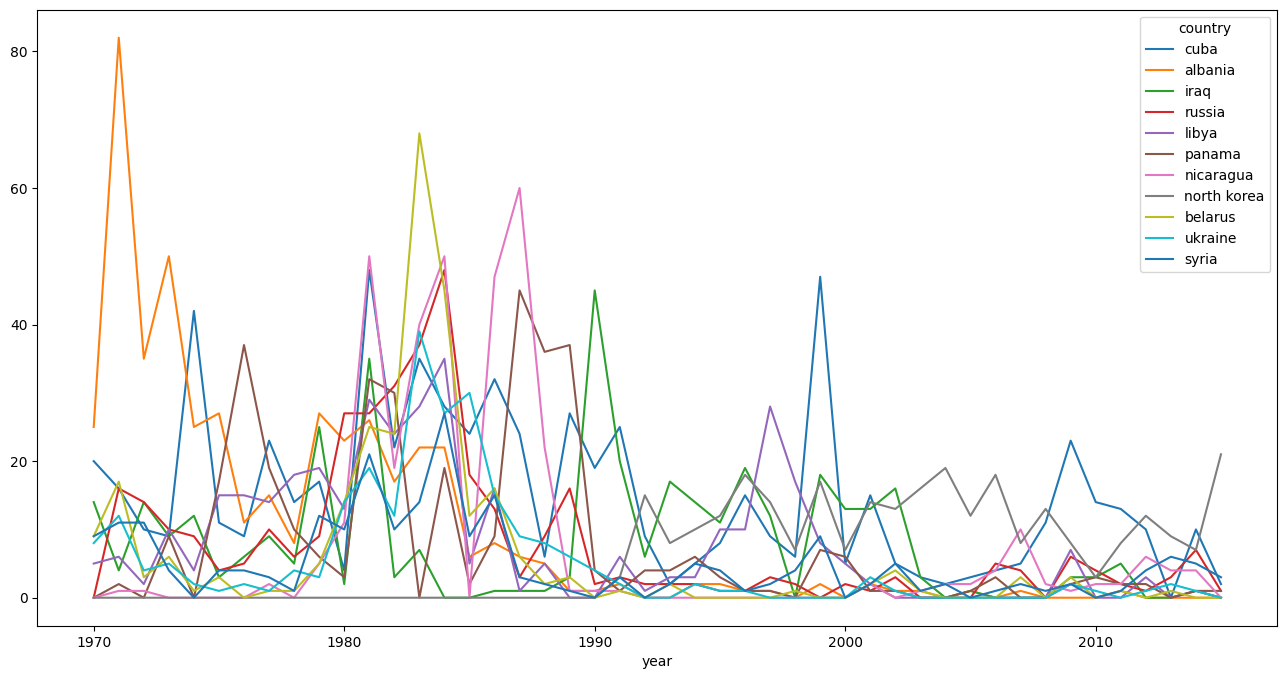

In [115]:
data.plot(x="year", y=countries_which_mention_usa,figsize=(16,8))
plt.show()

What Cuba says about USA in UN ?

In [117]:
data_future = data_future.loc[data_future['country'] == 'cuba']
data_future.head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



,session,year,country,text,token,usa_mentioned
98,44,1989,cuba,may i first on behalf of the people and gover...,"[may, i, first, on, behalf, of, the, people, a...",27
166,25,1970,cuba,1 mr president i should first like to congratu...,"[1, mr, president, i, should, first, like, to,...",20
317,68,2013,cuba,i have the honour to speak on behalf of the co...,"[i, have, the, honour, to, speak, on, behalf, ...",0
537,40,1985,cuba,forty years ago on the ruins of nazi fascism a...,"[forty, years, ago, on, the, ruins, of, nazi, ...",24
659,63,2008,cuba,mr president on behalf of cuba i would like to...,"[mr, president, on, behalf, of, cuba, i, would...",11


Lets, select only the talks where Cuba mentioned "USA" more than 10 times,

In [118]:
data_future = data_future.loc[data_future['usa_mentioned'] >= 10]

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



Lets, see which were the most frequent words except "usa" in these speechs,

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



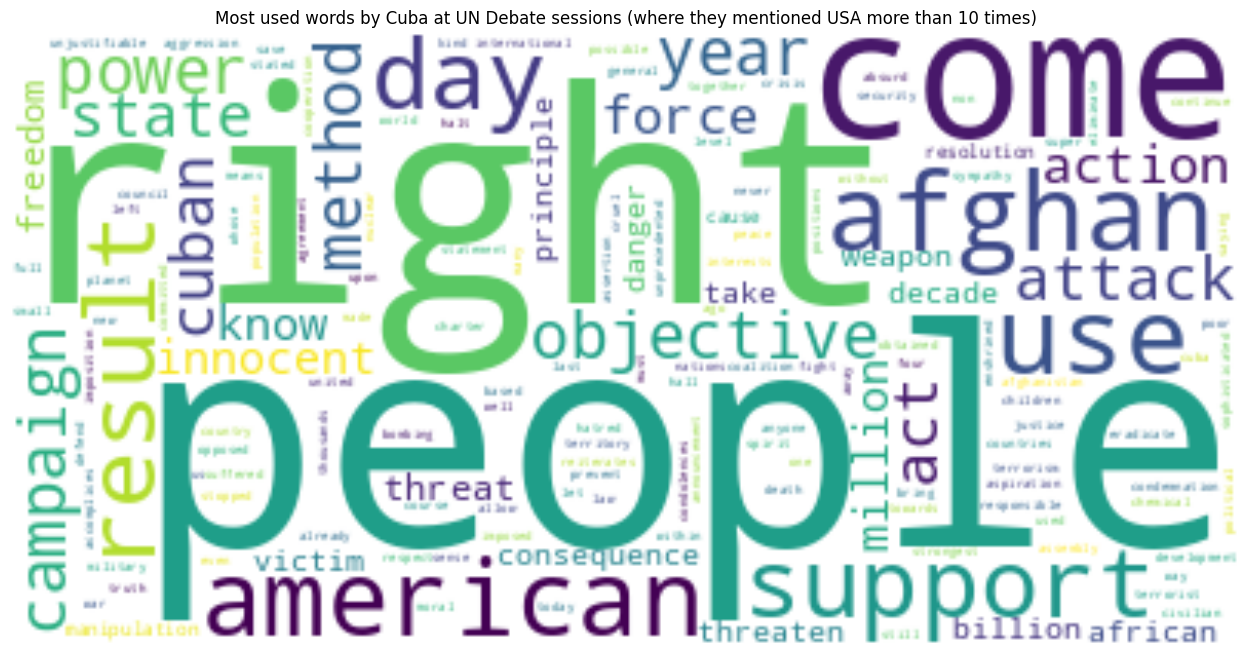

In [119]:
import nltk
from wordcloud import WordCloud, STOPWORDS

words = []
for i, row in data_future.iterrows():
    words = nltk.FreqDist(row['token'])

words = nltk.FreqDist(words)
stopwords = nltk.corpus.stopwords.words('english')
words_except_stop_dist = nltk.FreqDist(w for w in words if w not in stopwords)
wordcloud = WordCloud(stopwords=STOPWORDS,background_color='white').generate(" ".join(words_except_stop_dist))
plt.imshow(wordcloud,interpolation='bilinear')
fig=plt.gcf()
fig.set_size_inches(16,8)
plt.title("Most used words by Cuba at UN Debate sessions (where they mentioned USA more than 10 times)")
plt.axis('off')
plt.show()

In [120]:
#creating frequency of words
freqs = {}
for i, speech in data_future.iterrows():
    year = speech['year']
    for token in speech['token']:
        if token not in freqs:
            freqs[token] = {"total_freq":1, year:1}
        else:
            freqs[token]["total_freq"] += 1
            if not freqs[token].get(year):
                freqs[token][year] = 1
            else:
                freqs[token][year] += 1

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [121]:
data_future['sentiment'] = np.array([ analize_sentiment(text) for text in data_future['text'] ])
data_future['polarity'] = np.array([ analize_polarity(text) for text in data_future['text'] ])
data_future.head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



,session,year,country,text,token,usa_mentioned,sentiment,polarity
98,44,1989,cuba,may i first on behalf of the people and gover...,"[may, i, first, on, behalf, of, the, people, a...",27,0.9999,0.098
166,25,1970,cuba,1 mr president i should first like to congratu...,"[1, mr, president, i, should, first, like, to,...",20,0.9994,0.037
537,40,1985,cuba,forty years ago on the ruins of nazi fascism a...,"[forty, years, ago, on, the, ruins, of, nazi, ...",24,0.9998,0.036
659,63,2008,cuba,mr president on behalf of cuba i would like to...,"[mr, president, on, behalf, of, cuba, i, would...",11,0.8019,0.006
830,46,1991,cuba,we are extremely happy to welcome the admissi...,"[we, are, extremely, happy, to, welcome, the, ...",25,0.9997,0.038


In [123]:
import plotly.graph_objects as go
from plotly.offline import iplot


data = [go.Bar(
           x=data_future['year'],
           y=data_future['sentiment']
    )]

fig = go.Figure(data=data)
fig.update_layout(title='Sentiment Analysis Over Years',
                  xaxis_title='Year',
                  yaxis_title='Sentiment Score')

fig.show(renderer="colab")

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [124]:
stop_words.add("united states")
stop_words.add("cuba")
data_future['clean'] = data_future['token'].apply(lambda x: [w for w in x if not w in stop_words and not w in punctuation])

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [125]:
data_future['stems'] = [[format(get_lemma(token)) for token in speech] for speech in data_future['clean']]

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [126]:
data_future.head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



,session,year,country,text,token,usa_mentioned,sentiment,polarity,clean,stems
98,44,1989,cuba,may i first on behalf of the people and gover...,"[may, i, first, on, behalf, of, the, people, a...",27,0.9999,0.098,"[may, first, behalf, people, government, repub...","[may, first, behalf, people, government, repub..."
166,25,1970,cuba,1 mr president i should first like to congratu...,"[1, mr, president, i, should, first, like, to,...",20,0.9994,0.037,"[1, mr, president, first, like, congratulate, ...","[1, mr, president, first, like, congratulate, ..."
537,40,1985,cuba,forty years ago on the ruins of nazi fascism a...,"[forty, years, ago, on, the, ruins, of, nazi, ...",24,0.9998,0.036,"[forty, years, ago, ruins, nazi, fascism, infa...","[forty, years, ago, ruin, nazi, fascism, infam..."
659,63,2008,cuba,mr president on behalf of cuba i would like to...,"[mr, president, on, behalf, of, cuba, i, would...",11,0.8019,0.006,"[mr, president, behalf, would, like, congratul...","[mr, president, behalf, would, like, congratul..."
830,46,1991,cuba,we are extremely happy to welcome the admissi...,"[we, are, extremely, happy, to, welcome, the, ...",25,0.9997,0.038,"[extremely, happy, welcome, admission, members...","[extremely, happy, welcome, admission, members..."


In [127]:
#creating frequency of words
freqs = {}
for i, speech in data_future.iterrows():
    year = speech['year']
    for token in speech['stems']:
        if token not in freqs:
            freqs[token] = {"total_freq":1, year:1}
        else:
            freqs[token]["total_freq"] += 1
            if not freqs[token].get(year):
                freqs[token][year] = 1
            else:
                freqs[token][year] += 1

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [128]:
freqs_df = pd.DataFrame.from_dict(freqs, orient='index')
freqs_df['word'] = freqs_df.index
new_cols = ["total_freq", "word"] + sorted(freqs_df.columns.tolist()[1:-1])
freqs_df = freqs_df[new_cols]
freqs_df = freqs_df.sort_values('total_freq', ascending=False)
freqs_df = freqs_df.fillna(0)
freqs_df.head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



,total_freq,word,1970,1971,1972,1974,1975,1977,1978,1979,...,1991,1996,1999,2001,2008,2009,2010,2011,2012,2014
country,1001,country,27.0,16.0,32.0,77.0,25.0,52.0,41.0,187.0,...,39.0,27.0,56.0,11.0,26.0,15.0,13.0,13.0,8.0,17.0
state,986,state,25.0,33.0,24.0,49.0,24.0,44.0,43.0,53.0,...,41.0,27.0,61.0,19.0,15.0,26.0,19.0,21.0,19.0,25.0
unite,878,unite,32.0,24.0,23.0,58.0,21.0,34.0,24.0,34.0,...,40.0,29.0,55.0,20.0,12.0,27.0,20.0,19.0,14.0,14.0
people,592,people,30.0,25.0,32.0,29.0,33.0,35.0,36.0,29.0,...,37.0,8.0,23.0,15.0,8.0,7.0,7.0,8.0,5.0,7.0
international,532,international,13.0,9.0,20.0,24.0,20.0,25.0,25.0,64.0,...,12.0,15.0,14.0,9.0,10.0,7.0,12.0,6.0,4.0,21.0


In [131]:
import plotly.graph_objects as go

# Assuming freqs_df is your DataFrame containing word frequencies
# and total frequencies over the years

# Assuming freqs_df is already defined correctly

# Plot to visualize top 100 words over the years
trace = go.Scatter(
    x=freqs_df.iloc[0:100]['word'],
    y=freqs_df['total_freq']
)

layout = dict(
    title='Frequency of Words used over years by Cuba (USA Obsessed Speeches)',
    xaxis=dict(title='Word'),
    yaxis=dict(title='Count')
)

fig = go.Figure(data=[trace], layout=layout)

# Display the plot using fig.show()
fig.show(renderer="colab")


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



<Axes: title={'center': 'Word Frequency'}>

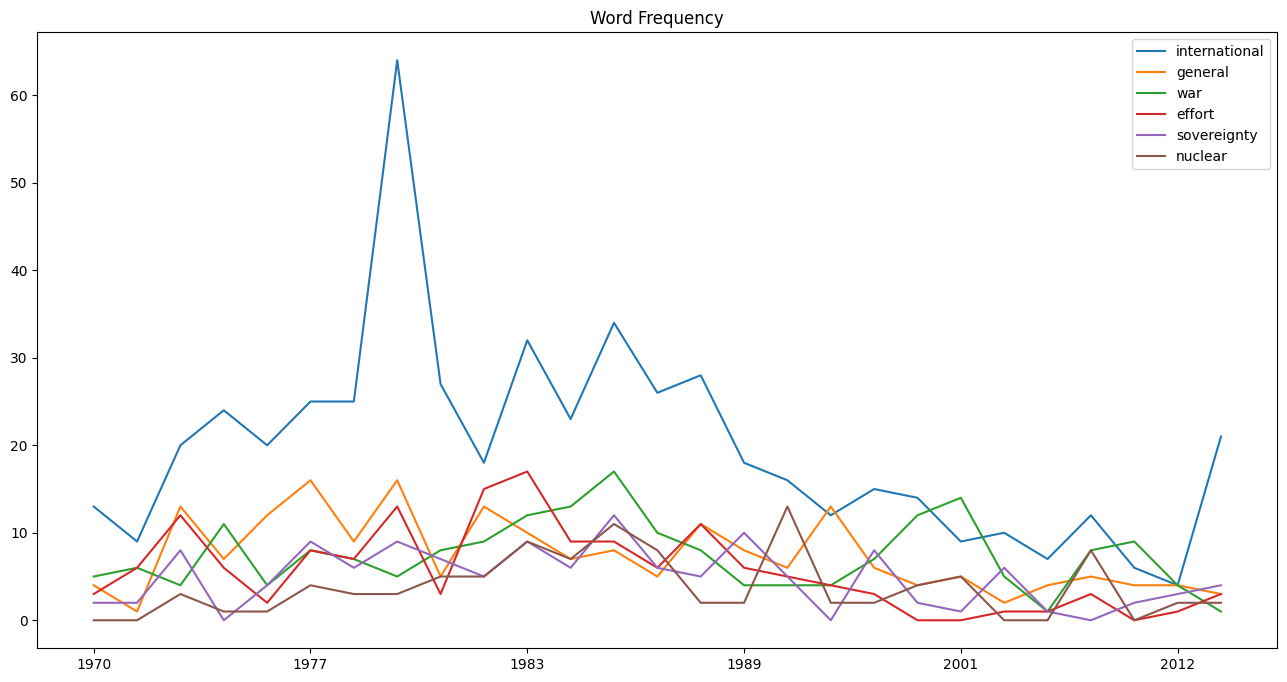

In [132]:
freqs_df[freqs_df['word'].isin(['international', 'war', 'effort', 'nuclear', 'general', 'sovereignty'])].iloc[:, 1:47].transpose().iloc[1:].plot(title="Word Frequency",figsize=(16,8))

In [133]:
text_data = list(data_future['clean'])

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [134]:
from gensim import corpora
dictionary = corpora.Dictionary(text_data)
corpus = [dictionary.doc2bow(text) for text in text_data]
import pickle
pickle.dump(corpus, open('corpus.pkl', 'wb'))
dictionary.save('dictionary.gensim')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [135]:
ldamodel = gensim.models.ldamodel.LdaModel(corpus, num_topics = 10, id2word=dictionary, passes=15)
ldamodel.save('model10.gensim')
topics = ldamodel.print_topics(num_words=4)
for topic in topics:
    print(topic)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



(0, '0.019*"countries" + 0.010*"world" + 0.010*"united" + 0.009*"international"')
(1, '0.009*"people" + 0.009*"countries" + 0.008*"united" + 0.008*"peoples"')
(2, '0.000*"countries" + 0.000*"people" + 0.000*"states" + 0.000*"united"')
(3, '0.000*"united" + 0.000*"states" + 0.000*"countries" + 0.000*"people"')
(4, '0.014*"states" + 0.014*"united" + 0.008*"people" + 0.008*"international"')
(5, '0.000*"states" + 0.000*"united" + 0.000*"countries" + 0.000*"people"')
(6, '0.011*"countries" + 0.011*"united" + 0.010*"states" + 0.009*"people"')
(7, '0.017*"united" + 0.015*"states" + 0.009*"people" + 0.008*"countries"')
(8, '0.012*"united" + 0.012*"states" + 0.009*"countries" + 0.009*"people"')
(9, '0.000*"countries" + 0.000*"united" + 0.000*"world" + 0.000*"international"')


Here's the topics Cuba speaks about USA at UN

In [136]:
import pyLDAvis.gensim
lda10 = gensim.models.ldamodel.LdaModel.load('model10.gensim')
lda_display10 = pyLDAvis.gensim.prepare(lda10, corpus, dictionary, sort_topics=False)
pyLDAvis.display(lda_display10)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.

